In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import sys
# sys.path.append('/DATACENTER4/jiangbo.chai/SWJTU_OOPAO')
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.MisRegistration import MisRegistration
from OOPAO.Pyramid import Pyramid
from OOPAO.ShackHartmann import ShackHartmann
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.calibration.ao_calibration import ao_calibration
from OOPAO.calibration.compute_KL_modal_basis import compute_M2C
from OOPAO.tools.displayTools import displayMap




     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


In [ ]:
# 创建望远镜
tel = Telescope(resolution          = 120, # 分辨率
                diameter            = 8, # 直径
                samplingTime        = 1/1000, # 采样时间
                centralObstruction  = 0) # 中心遮挡比例

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope


In [18]:
# 创建自然引导星
ngs=Source(optBand   = 'H', # 光波段
           magnitude = 0) # 星等，表示光源的亮度
ngs*tel

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       -0.0   2989130434.8
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
    Source NGS          1654.0             [nm]       
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
NGS(H) ~~> telescope


-> Computing the initial phase screen...
initial phase screen : 0.01193094253540039 s
ZZt.. : 2.5510213375091553 s
ZXt.. : 0.2951531410217285 s
XXt.. : 0.15279555320739746 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.007821798324584961 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 2.5272369384765625e-05 s
XXt.. : 6.9141387939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.007689714431762695 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 2.6226043701171875e-05 s
XXt.. : 6.67572021484375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!


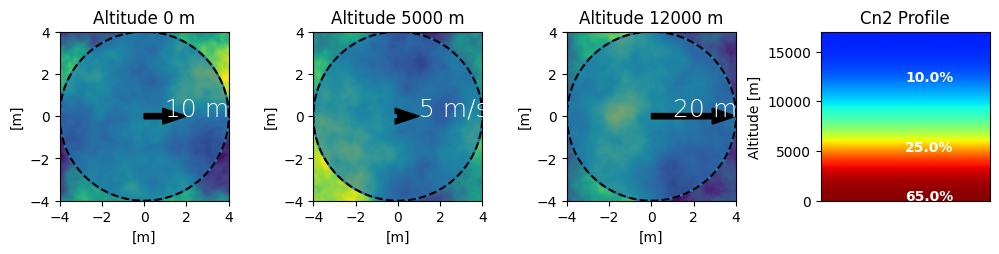

In [19]:
atm=Atmosphere(telescope     = tel,
               r0            = 0.16, # 大气湍流的弗里德参数（Fried parameter），表示大气相干长度，单位为米
               L0            = 30, # 大气湍流的外尺度（Outer scale），单位为米
               windSpeed     = [10,5,20] , # 每个湍流层的风速，单位为米/秒
               fractionalR0  = [0.65,0.25,0.1], # 每个湍流层的 Cn² 剖面，表示每个层对总湍流的贡献比例
               windDirection = [0,0,0], # 每个湍流层的风向，单位为度
               altitude      = [0, 5000,12000 ]) # 每个湍流层的海拔高度，单位为米
atm.initializeAtmosphere(telescope=tel) # 初始化
atm.display_atm_layers() # 可视化//第一个可以修改的参数，大气环境我们要怎么检测得到

In [20]:
atm.print_properties()

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% ATMOSPHERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%
   Layer     Direction     Speed      Altitude      Cn2     
               [deg]       [m/s]        [m]       [m-2/3]   
----------------------------------------------------------------------
     1           0           10          0          0.65    
------------------------------------------------------------------
     2           0           5          5000        0.25    
------------------------------------------------------------------
     3           0           20        12000        0.1     
------------------------------------------------------------------
    r0 @500 nm         0.16 [m]     
        L0              30 [m]      
  Seeing @500nm        0.64 ["]     
    Frequency        1000.0 [Hz]    
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [21]:
print(tel.isPaired)
tel+atm # 望远镜与大气结合
print(tel.isPaired)

False
True


In [22]:
# 创建变形镜
dm=DeformableMirror(telescope    = tel,
                    nSubap       = 32, # 沿望远镜直径的变形镜驱动器数，即总驱动数=nSubap*nSubap
                    mechCoupling = 0.45) # 驱动器之间的机械耦合系数,用于描述变形镜的各个驱动器之间的机械相互作用程度

No coordinates loaded.. taking the cartesian geometry as a default
Generating a Deformable Mirror: 
Computing the 2D zonal modes...
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% DEFORMABLE MIRROR %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Controlled Actuators        877        
         M4                False       
        Pitch               0.25              [m]        
 Mechanical Coupling        0.45              [%]        
-------------------------------------------------------------------------------
Mis-registration:
Rotation [deg]	Shift X [m]	Shift Y [m]	Radial Scaling [%]	Tangential Scaling [%]
      0       	     0     	     0     	        0         	          0           
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [36]:
# 创建SH-WFS 

wfs = ShackHartmann(nSubap              = 20, #  沿望远镜直径的子孔径数
                    telescope           = tel,
                    lightRatio          = 0.6, # 用于筛选有效子孔径
                    is_geometric        = False, # 是否启用几何模式（直接测量梯度）
                    threshold_cog       = 0.01,
                    shannon_sampling=True) # 计算光斑质心时的阈值
gainCL                  = 0.6  # 传感增益


Selecting valid subapertures based on flux considerations..


80520.0 True


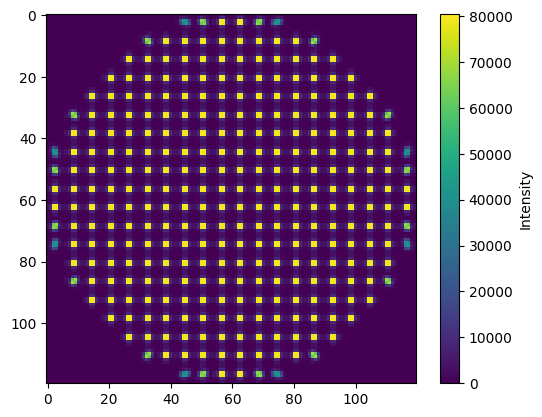

In [37]:
tel-atm
wfs.cam.photonNoise=True
ngs*tel*wfs
plt.imshow(wfs.cam.frame)
plt.colorbar(label='Intensity')
print(wfs.cam.frame.max(),wfs.cam.photonNoise)

290876.0 True


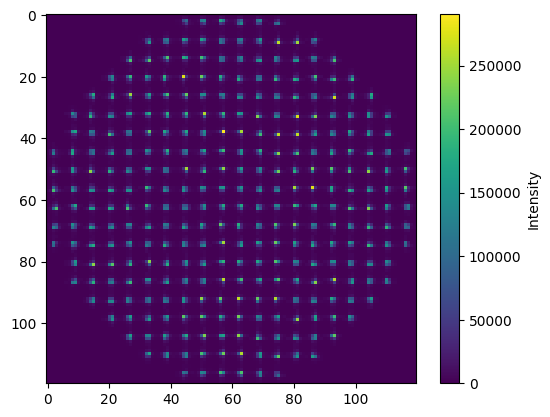

In [35]:
tel+atm
wfs.cam.photonNoise=True
ngs*tel*wfs
plt.imshow(wfs.cam.frame)
plt.colorbar(label='Intensity')
print(wfs.cam.frame.max(),wfs.cam.photonNoise)

In [15]:
from tutorials.scao_system.parameter_files.parameterFile_VLT_I_Band_SHWFS import initializeParameterFile

param = initializeParameterFile()

'''
加载或生成模态基,即模式到控制矩阵（M2C）用于将模式映射到变形镜（DM）的控制信号
计算或加载交互矩阵
'''
ao_calib =  ao_calibration(param            = param,\
                           ngs              = ngs,\
                           tel              = tel,\
                           atm              = atm,\
                           dm               = dm,\
                           wfs              = wfs,\
                           nameFolderIntMat = None,\
                           nameIntMat       = None,\
                           nameFolderBasis  = None,\
                           nameBasis        = None,\
                           nMeasurements    = 100)


Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_I_band_20x20/zonal_interaction_matrix_120_res_772_subap_diffractive...
ERROR: No file found! computing imat..
Interaction Matrix Computation:


 11%|█         | 1/9 [01:04<08:35, 64.47s/it]

100/856
Time elapsed: 64.46715497970581 s


 22%|██▏       | 2/9 [01:59<06:51, 58.84s/it]

200/856
Time elapsed: 54.903087854385376 s


...

 89%|████████▉ | 8/9 [04:55<00:27, 27.03s/it]

800/856
Time elapsed: 19.69688892364502 s


100%|██████████| 9/9 [05:06<00:00, 34.07s/it]

900/856
Time elapsed: 11.036466121673584 s


No Modal Gains found. All gains set to 1


In [16]:
ao_calib.M2C.shape
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

In [ ]:
# 闭环控制

atm.initializeAtmosphere(telescope=tel)
tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 100
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
SR_ = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 0.6  # 传感增益
wfs.cam.photonNoise     = True
display                 = True
a=time.time()
for i in range(param['nLoop']):
    
    # 更新所有湍流层的相位屏，模拟时间演化
    atm.update()
    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
       
    tel*dm*wfs
    '''
    更新DM的控制信号
    dm.coefs：变形镜的控制系数，表示每个驱动器的位移量。 11111
    
    gainCL：闭环控制增益，用于调节校正的强度    11111
    波前传感器的增益,而采样频率通常是和望远镜的采样频率同步的
    
    M2C_CL：模式到控制矩阵，用于将模式映射到变形镜的控制信号。
    calib_CL.M：交互矩阵的伪逆矩阵，用于将波前传感器的信号转换为模式系数。
    wfsSignal:shwfs测量的斜率，形状：（2*nValidSubaperture,）
    ''' 
    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    wfsSignal=wfs.signal
    
    
    
    
    #实际代码的SR比不通过图像的比来得到，而使用近似的相位差来得到，
    #后续需要修改 改成用科学成像相机的方式来测量斯特列尔比
    SR[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+'-- SR:'+str('%.4f'%SR[i])+'\n')
b= time.time()
print('SR_old_mean:',np.mean(SR))


1

2

3

Loop0/100 Turbulence: 826.4774280371914 -- Residual:826.4774280371914-- SR:0.0001

1

2

3

Loop1/100 Turbulence: 826.5720186604576 -- Residual:826.5720186604576-- SR:0.0001

1

2

3

Loop2/100 Turbulence: 826.6811690825425 -- Residual:326.465073609823-- SR:0.2148

1

2

3

Loop3/100 Turbulence: 826.8340296311945 -- Residual:197.2234305654665-- SR:0.5705

1

2

3

Loop4/100 Turbulence: 826.9424698971796 -- Residual:390.51827351663206-- SR:0.1107

1

2

3

Loop5/100 Turbulence: 827.0181272190114 -- Residual:279.64697777703367-- SR:0.3235

1

2

3

Loop6/100 Turbulence: 827.1503293123955 -- Residual:81.33601839387327-- SR:0.9089

1

2

3

Loop7/100 Turbulence: 827.2625829684026 -- Residual:151.08567570401266-- SR:0.7193

1

2

3

Loop8/100 Turbulence: 827.3256011949713 -- Residual:166.9001819495595-- SR:0.6690

1

2

3

Loop9/100 Turbulence: 827.4394650643267 -- Residual:99.38976733329383-- SR:0.8671

1

2

3

Loop10/100 Turbulence: 827.5373707717368 -- Residual:79.8133841358922

Text(0, 0.5, 'WFE [nm]')

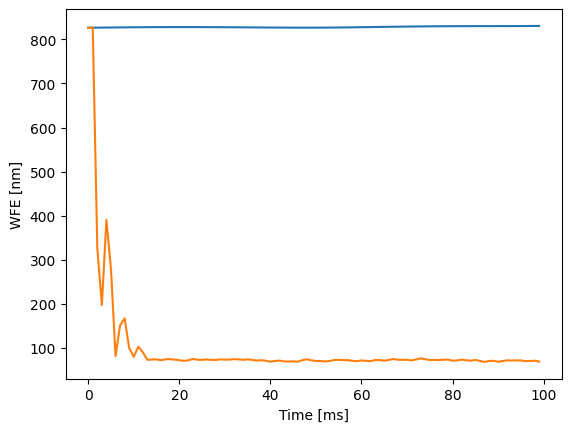

In [18]:
# 波前误差
plt.figure()
plt.plot(total)
plt.plot(residual)
plt.xlabel('Time [ms]')
plt.ylabel('WFE [nm]')


Text(0, 0.5, 'SR')

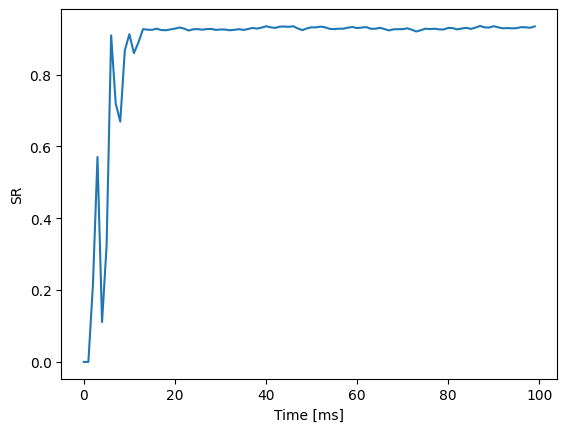

In [19]:
plt.plot(SR)
plt.xlabel('Time [ms]')
plt.ylabel('SR')

Loop 1/100 - SR_camH: 0.01,SR_old:0.00
Loop 2/100 - SR_camH: 0.01,SR_old:0.00
Loop 3/100 - SR_camH: 0.03,SR_old:0.00
Loop 4/100 - SR_camH: 0.43,SR_old:0.43
Loop 5/100 - SR_camH: 0.05,SR_old:0.03
Loop 6/100 - SR_camH: 0.07,SR_old:0.05
Loop 7/100 - SR_camH: 0.37,SR_old:0.37
Loop 8/100 - SR_camH: 0.48,SR_old:0.44
Loop 9/100 - SR_camH: 0.40,SR_old:0.32
Loop 10/100 - SR_camH: 0.45,SR_old:0.39
Loop 11/100 - SR_camH: 0.52,SR_old:0.49
Loop 12/100 - SR_camH: 0.50,SR_old:0.49
Loop 13/100 - SR_camH: 0.49,SR_old:0.48
Loop 14/100 - SR_camH: 0.51,SR_old:0.50
Loop 15/100 - SR_camH: 0.52,SR_old:0.51
Loop 16/100 - SR_camH: 0.52,SR_old:0.52
Loop 17/100 - SR_camH: 0.53,SR_old:0.52
Loop 18/100 - SR_camH: 0.53,SR_old:0.53
Loop 19/100 - SR_camH: 0.52,SR_old:0.52
Loop 20/100 - SR_camH: 0.52,SR_old:0.52
Loop 21/100 - SR_camH: 0.52,SR_old:0.51
Loop 22/100 - SR_camH: 0.52,SR_old:0.51
Loop 23/100 - SR_camH: 0.52,SR_old:0.51
Loop 24/100 - SR_camH: 0.52,SR_old:0.52
Loop 25/100 - SR_camH: 0.54,SR_old:0.54
Loop 26/1

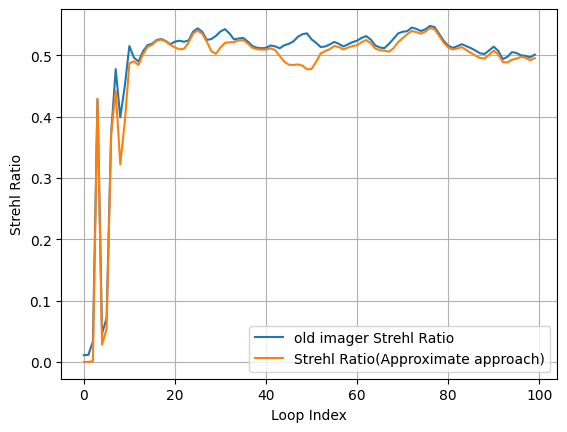

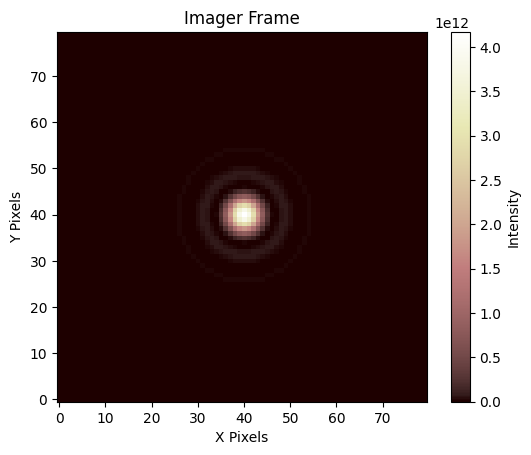

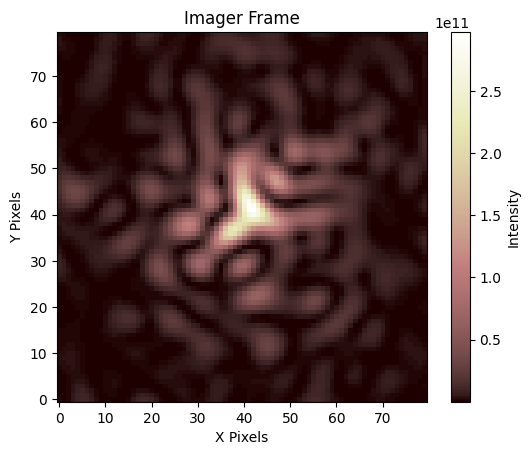

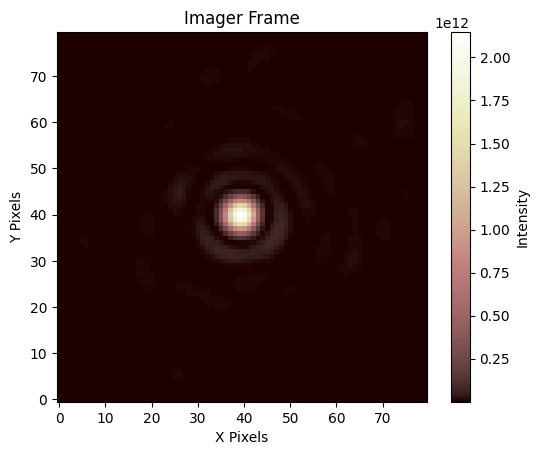

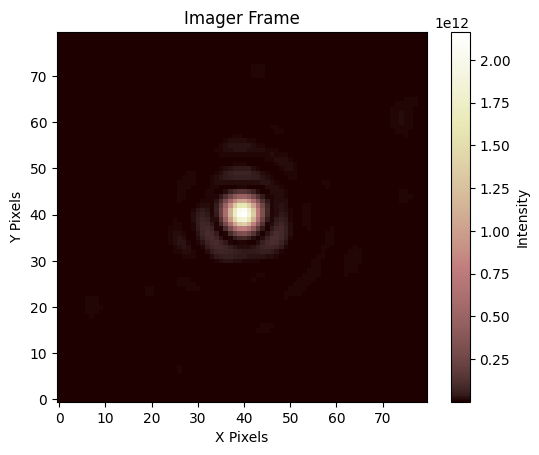

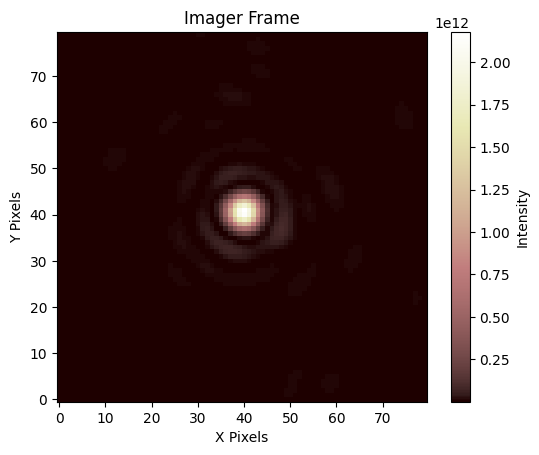

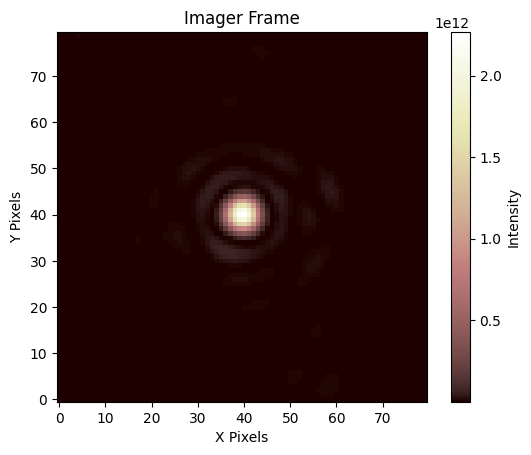

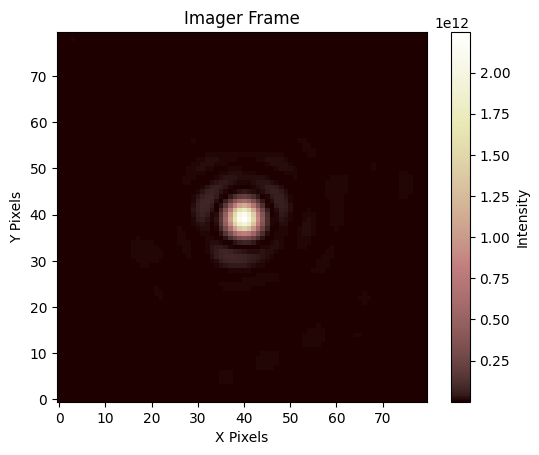

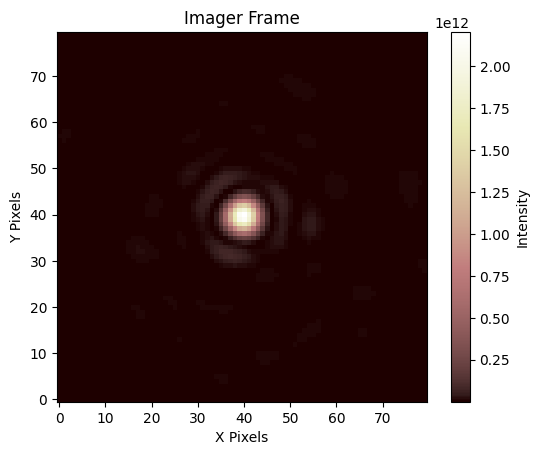

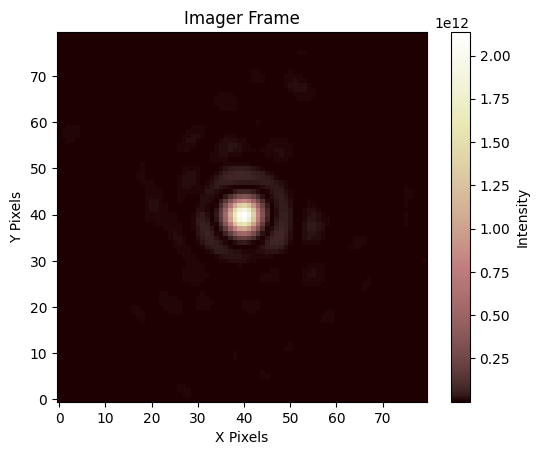

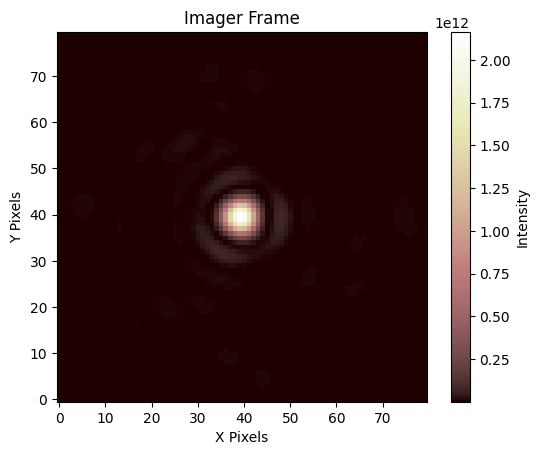

In [23]:
from Imager import Imager
tel-atm
camH = Imager(nyquist_sampling=4,field_stop_size=10,exposure_time=10,clock_rate=1)
camH.relay(tel.src)
camH.reference_frame = camH.frame
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0

frame_list = []
frame_list.append(camH.reference_frame)
param['nLoop'] = 100
SR_camH = np.zeros(param['nLoop'])  # 斯特列尔比
SR_old = np.zeros(param['nLoop'])  # 近似方式斯特列尔比
total = np.zeros(param['nLoop'])  # 总波前误差
residual = np.zeros(param['nLoop'])  # 残余波前误差
wfsSignal = np.zeros(wfs.nSignal)  # 波前传感器信号

wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 0.6  # 传感增益
wfs.cam.photonNoise     = True
atm.initializeAtmosphere(telescope=tel)
display                 = True

for i in range(param['nLoop']):

    atm.update()
    tel-atm
    camH.relay(tel.src)
    camH.reference_frame = camH.frame
    tel+atm

    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
       
    tel*dm*wfs
    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    
    wfsSignal=wfs.signal

    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    camH.relay(tel.src)

    if len(frame_list)<10 and i>0 and i%5==0:
        frame_list.append(camH.frame)

    SR_camH[i] = camH.strehl  # 科学相机计算的斯特列尔比
    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))

    print(f'Loop {i+1}/{param["nLoop"]} - SR_camH: {SR_camH[i]:.2f},SR_old:{SR_old[i]:.2f}')


plt.figure()
plt.plot(np.arange(param['nLoop']), SR_camH, label='old imager Strehl Ratio')
plt.plot(np.arange(param['nLoop']), SR_old, label='Strehl Ratio(Approximate approach)')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.legend()
plt.grid()
plt.show()

for frame in frame_list:
    plt.imshow(frame, cmap='pink', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title('Imager Frame')
    plt.xlabel('X Pixels')
    plt.ylabel('Y Pixels')
    plt.show()

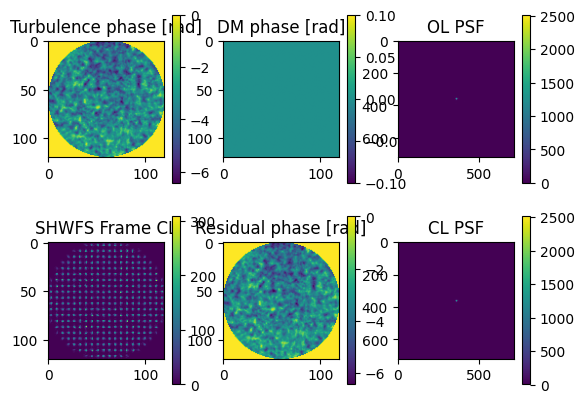

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.0755763053894043 s
Loop0/20 Turbulence: 685.7846351055375 -- Residual:685.7846351055375

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.07514786720275879 s
Loop1/20 Turbulence: 687.0947527411316 -- Residual:687.0947527411316

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.07573151588439941 s
Loop2/20 Turbulence: 688.4473709526379 -- Residual:337.60771940402054

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.07366514205932617 s
Loop3/20 Turbulence: 689.8224802800393 -- Residual:110.97543272791155

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.07501101493835449 s
Loop4/20 Turbulence: 691.2484692273262 -- Residual:239.6086912554532

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.0780642032623291 s
Loop5/20 Turbulence: 692.6847922703635 -- Residual:218.29764350785797

(357,) (357, 664) (664,)
(120, 120)
Elapsed time: 0.07624530792236328 s
Loop6/20 Turbulence: 694.1165288571384 -- Residual:123.62303065414967

(357

In [ ]:
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0

im_atm_list = []
im_dm_list = []
im_PSF_OL_list = []
im_wfs_CL_list = []
im_residual_list = []
im_PSF_list = []
plt.ion()
# setup the display
fig         = plt.figure(79)
ax1         = plt.subplot(2,3,1)
im_atm      = ax1.imshow(tel.src.phase)
plt.colorbar(im_atm)
plt.title('Turbulence phase [rad]')


ax2         = plt.subplot(2,3,2)
im_dm       = ax2.imshow(dm.OPD*tel.pupil)
plt.colorbar(im_dm)
plt.title('DM phase [rad]')
tel.computePSF(zeroPaddingFactor=6)

ax4         = plt.subplot(2,3,3)
im_PSF_OL   = ax4.imshow(tel.PSF)
plt.colorbar(im_PSF_OL)
plt.title('OL PSF')


ax3         = plt.subplot(2,3,5)
im_residual = ax3.imshow(tel.src.phase)
plt.colorbar(im_residual)
plt.title('Residual phase [rad]')

ax5         = plt.subplot(2,3,4)
im_wfs_CL   = ax5.imshow(wfs.cam.frame)
plt.colorbar(im_wfs_CL)
plt.title('SHWFS Frame CL')

ax6         = plt.subplot(2,3,6)
im_PSF      = ax6.imshow(tel.PSF)
plt.colorbar(im_PSF)
plt.title('CL PSF')

plt.show()

param['nLoop'] = 20
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 0.6  # 增益
wfs.cam.photonNoise     = True
display                 = True

for i in range(param['nLoop']):
    a=time.time()
    # 更新所有湍流层的相位屏，模拟时间演化
    atm.update()
    # 记录总的波前误差
    # tel.pupil>0表示能够接收到光的位置
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
     # save turbulent phase
    turbPhase = tel.src.phase
    if display == True:
        # compute the OL PSF and update the display
        tel.computePSF(zeroPaddingFactor=6)
        im_PSF_OL_list.append(np.log(tel.PSF/tel.PSF.max()))

     # propagate to the WFS with the CL commands applied
    tel*dm*wfs

     # save the DM OPD shape
    dmOPD=tel.pupil*dm.OPD*2*np.pi/ngs.wavelength



    '''
    更新DM的控制信号
    dm.coefs：变形镜的控制系数，表示每个驱动器的位移量。
    gainCL：闭环控制增益，用于调节校正的强度
    M2C_CL：模式到控制矩阵，用于将模式映射到变形镜的控制信号。
    calib_CL.M：交互矩阵的伪逆矩阵，用于将波前传感器的信号转换为模式系数。
    wfsSignal:shwfs测量的斜率，形状：（2*nValidSubaperture,）
    ''' 
    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    print(dm.coefs.shape,calib_CL.M.shape, wfsSignal.shape)
    print(wfs.cam.frame.shape)


     # store the slopes after computing the commands => 2 frames delay
    wfsSignal=wfs.signal
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')
    # update displays if required
    if display==True:

       # Turbulence
       im_atm_list.append(turbPhase)
       # WFS frame
       C=wfs.cam.frame
       im_wfs_CL_list.append(C)
       # DM OPD
       im_dm_list.append(dmOPD)

       # residual phase
       D=tel.src.phase
       D=D-np.mean(D[tel.pupil])
       im_residual_list.append(D)

       tel.computePSF(zeroPaddingFactor=6)
       im_PSF_list.append(np.log(tel.PSF/tel.PSF.max()))


    SR[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    OPD=tel.OPD[np.where(tel.pupil>0)]

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')


loop 5


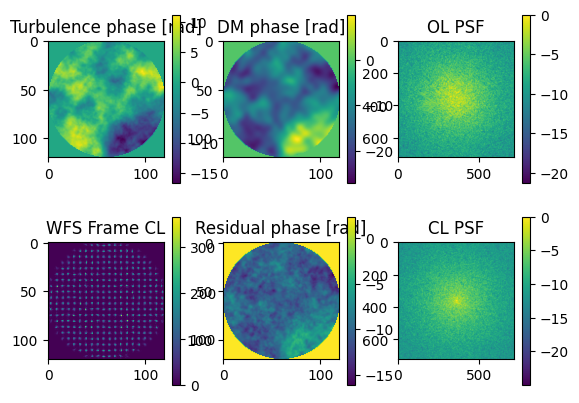

loop 10


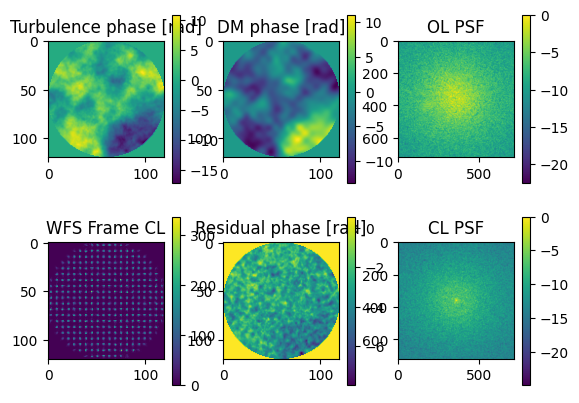

loop 15


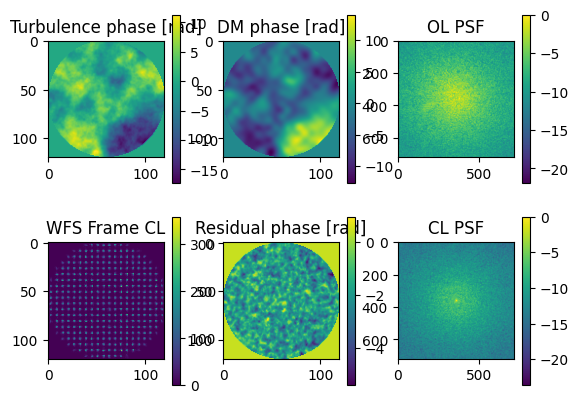

loop 20


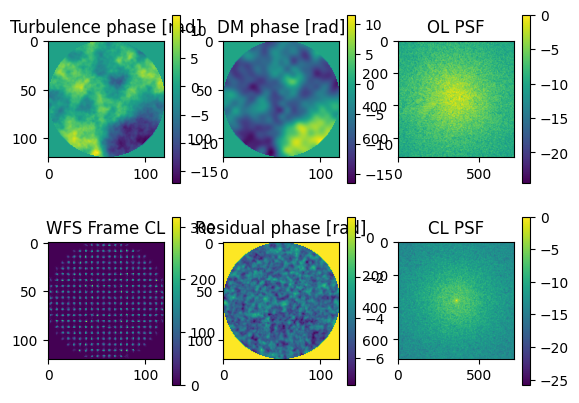

In [ ]:
for i in range(20):
    if (i+1) % 5==0:
        print('loop %d' % (i+1))
        plt.subplot(2,3,1)
        im_atm = plt.imshow(im_atm_list[i])
        plt.colorbar(im_atm)
        plt.title('Turbulence phase [rad]')

        plt.subplot(2,3,2)
        im_dm = plt.imshow(im_dm_list[i])
        plt.colorbar(im_dm)
        plt.title('DM phase [rad]')

        plt.subplot(2,3,3)
        im_PSF_OL   = plt.imshow(im_PSF_OL_list[i])
        plt.colorbar(im_PSF_OL)
        plt.title('OL PSF')

        plt.subplot(2,3,4)
        im_wfs_CL   = plt.imshow(im_wfs_CL_list[i])
        plt.colorbar(im_wfs_CL)
        plt.title('WFS Frame CL')

        plt.subplot(2,3,5)
        im_residual = plt.imshow(im_residual_list[i])
        plt.colorbar(im_residual)
        plt.title('Residual phase [rad]')

        plt.subplot(2,3,6)
        im_PSF      = plt.imshow(im_PSF_list[i])
        plt.colorbar(im_PSF)
        plt.title('CL PSF')

        plt.show()


## 噪声设置
总的波前误差相同，有噪声情况下SR更低，残余波前误差更大，且更不稳定


In [ ]:
from collections import deque


# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 


# loop parameters
gainCL                  = 0.6  # 传感增益
def run(photonNoise=False, readoutNoise=0, darkCurrent=0, n=20, delay=0):
    wfs.cam.photonNoise = photonNoise
    wfs.cam.readoutNoise = readoutNoise
    wfs.cam.darkCurrent = darkCurrent

    atm.initializeAtmosphere(tel)
    dm.coefs=0
    tel+atm
    ngs*tel*dm*wfs  

    SR                      = np.zeros(n) # 斯特列尔比
    total                   = np.zeros(n)
    residual                = np.zeros(n)
    wfsSignal               = np.arange(0,wfs.nSignal)*0

    wfs_buffer = deque([np.zeros(wfs.nSignal)] * (delay+1), maxlen=delay+1)
    coefs_list = np.zeros(n)

    for i in range(n):

        # 更新所有湍流层的相位屏，模拟时间演化
        atm.update()
        # 记录总的波前误差
        total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
        
        tel*dm*wfs

        current_signal = wfs.signal.copy()
        
        # 存入队列
        wfs_buffer.append(current_signal)

        # 取出延迟后的信号
        delayed_signal = wfs_buffer[0]  

        dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@delayed_signal
        coefs_list[i] = np.mean(dm.coefs)
        # coefs_list[i] = np.linalg.norm(dm.coefs) / np.sqrt(len(dm.coefs))
        
        SR[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
        residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9

        print('Loop'+str(i)+'/'+str(n)+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')
    return SR, total, residual, coefs_list



    


In [ ]:
n = 1000 # 帧数
SR_no_noise, total_no_noise, residual_no_noise,_ = run(n=n)

Elapsed time: 0.03765153884887695 s
Loop0/1000 Turbulence: 662.1506368880488 -- Residual:662.1506368880488

Elapsed time: 0.04033946990966797 s
Loop1/1000 Turbulence: 663.270989389561 -- Residual:323.4547149726259

Elapsed time: 0.04163336753845215 s
Loop2/1000 Turbulence: 664.4645111096315 -- Residual:171.76997426259229

Elapsed time: 0.04338955879211426 s
Loop3/1000 Turbulence: 665.6556443707079 -- Residual:119.52004475667299

Elapsed time: 0.04564929008483887 s
Loop4/1000 Turbulence: 666.861096224678 -- Residual:107.09811215235389

Elapsed time: 0.0453801155090332 s
Loop5/1000 Turbulence: 668.0216193963943 -- Residual:105.3057077472593

Elapsed time: 0.045276641845703125 s
Loop6/1000 Turbulence: 669.0756829459334 -- Residual:105.62712786130565

Elapsed time: 0.04015779495239258 s
Loop7/1000 Turbulence: 670.1414037622908 -- Residual:105.60557661095632

Elapsed time: 0.03979086875915527 s
Loop8/1000 Turbulence: 671.2472310673679 -- Residual:105.08594027925379

Elapsed time: 0.04451322

In [ ]:
photonNoise = True # 光子噪声
readoutNoise = 20 # 读出噪声
darkCurrent = 0.5 # 暗电流
SR_with_noise, total_with_noise, residual_with_noise, _ = run(photonNoise, readoutNoise, darkCurrent, n)

Elapsed time: 0.03973078727722168 s
Loop0/1000 Turbulence: 662.1506368880488 -- Residual:662.1506368880488

Elapsed time: 0.04195427894592285 s
Loop1/1000 Turbulence: 663.270989389561 -- Residual:428.85033262615514

Elapsed time: 0.04195594787597656 s
Loop2/1000 Turbulence: 664.4645111096315 -- Residual:305.61502342808853

Elapsed time: 0.04015684127807617 s
Loop3/1000 Turbulence: 665.6556443707079 -- Residual:228.93266903494916

Elapsed time: 0.04320979118347168 s
Loop4/1000 Turbulence: 666.861096224678 -- Residual:164.63007781225485

Elapsed time: 0.04449772834777832 s
Loop5/1000 Turbulence: 668.0216193963943 -- Residual:131.97342274656518

Elapsed time: 0.04572749137878418 s
Loop6/1000 Turbulence: 669.0756829459334 -- Residual:127.55408355997254

Elapsed time: 0.040621280670166016 s
Loop7/1000 Turbulence: 670.1414037622908 -- Residual:137.06913638980197

Elapsed time: 0.040259599685668945 s
Loop8/1000 Turbulence: 671.2472310673679 -- Residual:136.09558888843566

Elapsed time: 0.0450

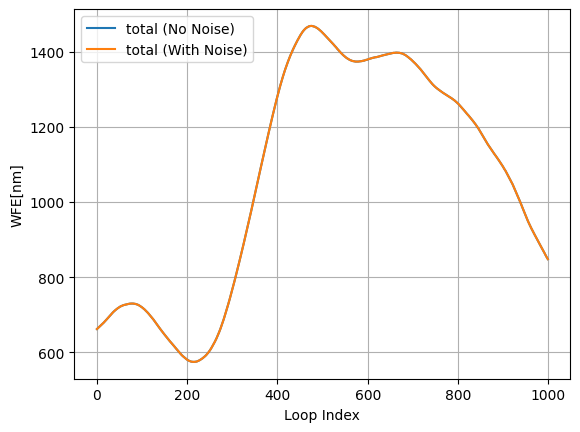

In [ ]:
plt.figure()
plt.plot(total_no_noise, label="total (No Noise)")
plt.plot(total_with_noise, label="total (With Noise)")
plt.xlabel("Loop Index")
plt.ylabel("WFE[nm]")
plt.title("")
plt.legend()
plt.grid()

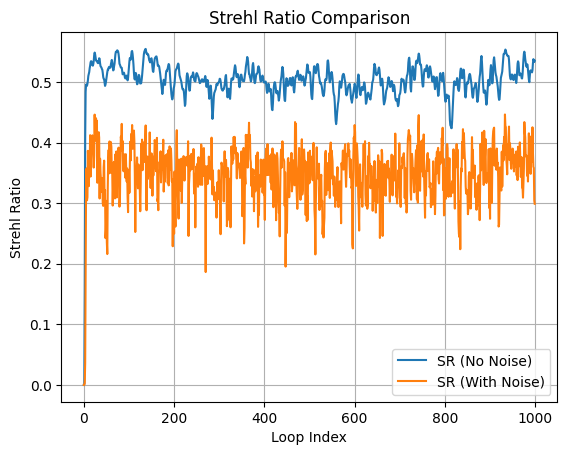

In [ ]:
plt.figure()
plt.plot(SR_no_noise, label="SR (No Noise)")
plt.plot(SR_with_noise, label="SR (With Noise)")
plt.xlabel("Loop Index")
plt.ylabel("Strehl Ratio")
plt.title("Strehl Ratio Comparison")
plt.legend()
plt.grid()

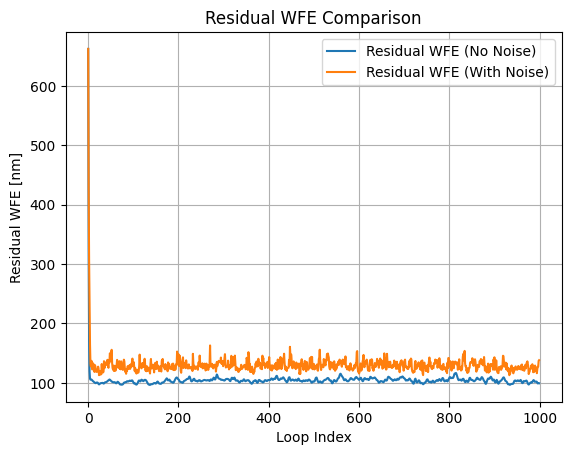

In [ ]:
plt.figure()
plt.plot(residual_no_noise, label="Residual WFE (No Noise)")
plt.plot(residual_with_noise, label="Residual WFE (With Noise)")
plt.xlabel("Loop Index")
plt.ylabel("Residual WFE [nm]")
plt.title("Residual WFE Comparison")
plt.legend()
plt.grid()

## 延迟设置

In [ ]:
gainCL = 0.3
SR_no_delay, total_no_delay, residual_no_delay, coefs_no_delay = run(n=200)


Elapsed time: 0.04607272148132324 s
Loop0/200 Turbulence: 662.1506368880488 -- Residual:662.1506368880488

Elapsed time: 0.051339149475097656 s
Loop1/200 Turbulence: 663.270989389561 -- Residual:491.80403700438734

Elapsed time: 0.05311155319213867 s
Loop2/200 Turbulence: 664.4645111096315 -- Residual:366.2819339062032

Elapsed time: 0.05122947692871094 s
Loop3/200 Turbulence: 665.6556443707079 -- Residual:275.5396031909319

Elapsed time: 0.05783557891845703 s
Loop4/200 Turbulence: 666.861096224678 -- Residual:212.77548695658243

Elapsed time: 0.055036067962646484 s
Loop5/200 Turbulence: 668.0216193963943 -- Residual:171.74355337114372

Elapsed time: 0.05984091758728027 s
Loop6/200 Turbulence: 669.0756829459334 -- Residual:145.92598466383095

Elapsed time: 0.05157876014709473 s
Loop7/200 Turbulence: 670.1414037622908 -- Residual:130.15367098150944

Elapsed time: 0.05340909957885742 s
Loop8/200 Turbulence: 671.2472310673679 -- Residual:120.73168680393862

Elapsed time: 0.060515403747558

In [ ]:
SR_with_delay, total_with_delay, residual_with_delay, coefs_with_delay = run(n=200, delay=2)

Elapsed time: 0.03745460510253906 s
Loop0/200 Turbulence: 662.1506368880488 -- Residual:662.1506368880488

Elapsed time: 0.0420069694519043 s
Loop1/200 Turbulence: 663.270989389561 -- Residual:663.270989389561

Elapsed time: 0.04237556457519531 s
Loop2/200 Turbulence: 664.4645111096315 -- Residual:664.4645111096315

Elapsed time: 0.04210638999938965 s
Loop3/200 Turbulence: 665.6556443707079 -- Residual:494.5423724725301

Elapsed time: 0.043027400970458984 s
Loop4/200 Turbulence: 666.861096224678 -- Residual:327.8996703473267

Elapsed time: 0.04205179214477539 s
Loop5/200 Turbulence: 668.0216193963943 -- Residual:175.83399690041446

Elapsed time: 0.045383453369140625 s
Loop6/200 Turbulence: 669.0756829459334 -- Residual:115.75472649244455

Elapsed time: 0.04371476173400879 s
Loop7/200 Turbulence: 670.1414037622908 -- Residual:140.77517198412409

Elapsed time: 0.04439902305603027 s
Loop8/200 Turbulence: 671.2472310673679 -- Residual:163.89606144292011

Elapsed time: 0.048885345458984375 

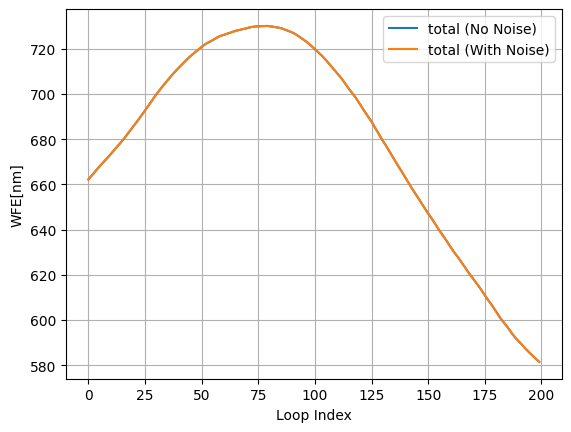

In [ ]:
plt.figure()
plt.plot(total_no_delay, label="total (No Noise)")
plt.plot(total_with_delay, label="total (With Noise)")
plt.xlabel("Loop Index")
plt.ylabel("WFE[nm]")
plt.title("")
plt.legend()
plt.grid()

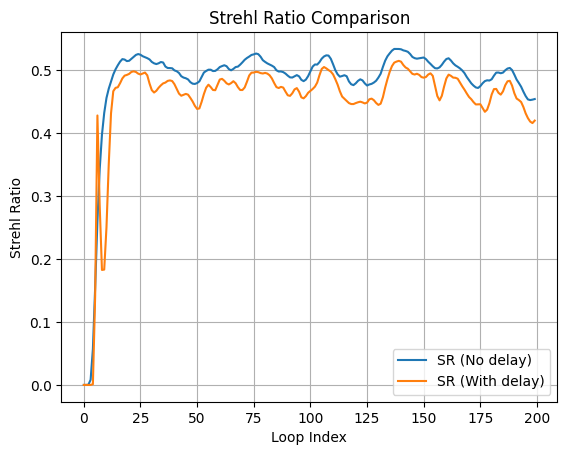

In [ ]:
plt.figure()
plt.plot(SR_no_delay, label="SR (No delay)")
plt.plot(SR_with_delay, label="SR (With delay)")
plt.xlabel("Loop Index")
plt.ylabel("Strehl Ratio")
plt.title("Strehl Ratio Comparison")
plt.legend()
plt.grid()

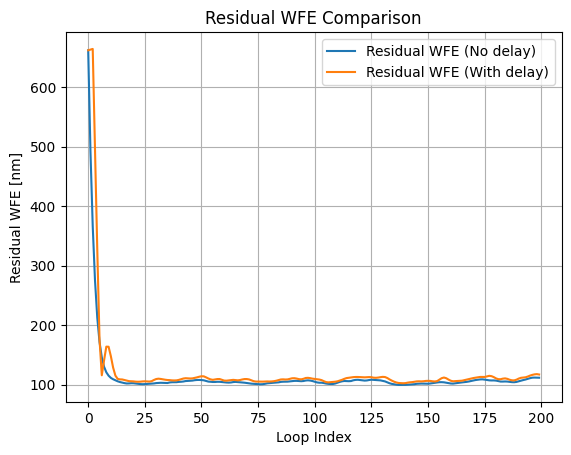

In [ ]:
plt.figure()
plt.plot(residual_no_delay, label="Residual WFE (No delay)")
plt.plot(residual_with_delay, label="Residual WFE (With delay)")
plt.xlabel("Loop Index")
plt.ylabel("Residual WFE [nm]")
plt.title("Residual WFE Comparison")
plt.legend()
plt.grid()

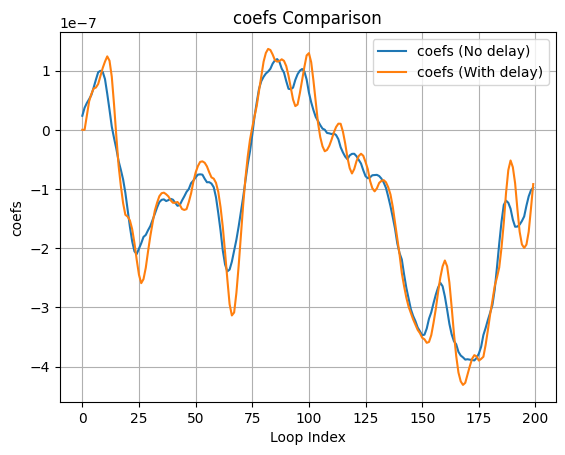

In [ ]:
plt.figure()
plt.plot(coefs_no_delay, label="coefs (No delay)")
plt.plot(coefs_with_delay, label="coefs (With delay)")
plt.xlabel("Loop Index")
plt.ylabel("coefs")
plt.title("coefs Comparison")
plt.legend()
plt.grid()

Loop 0/20, SR=0.000, SR_theory=0.265
Loop 1/20, SR=0.000, SR_theory=0.265
Loop 2/20, SR=0.000, SR_theory=0.265
Loop 3/20, SR=0.008, SR_theory=0.265
Loop 4/20, SR=0.057, SR_theory=0.265
Loop 5/20, SR=0.155, SR_theory=0.265
Loop 6/20, SR=0.260, SR_theory=0.265
Loop 7/20, SR=0.342, SR_theory=0.265
Loop 8/20, SR=0.398, SR_theory=0.265
Loop 9/20, SR=0.433, SR_theory=0.265
Loop 10/20, SR=0.456, SR_theory=0.265
Loop 11/20, SR=0.471, SR_theory=0.265
Loop 12/20, SR=0.482, SR_theory=0.265
Loop 13/20, SR=0.494, SR_theory=0.265
Loop 14/20, SR=0.502, SR_theory=0.265
Loop 15/20, SR=0.508, SR_theory=0.265
Loop 16/20, SR=0.514, SR_theory=0.265
Loop 17/20, SR=0.518, SR_theory=0.265
Loop 18/20, SR=0.517, SR_theory=0.265
Loop 19/20, SR=0.515, SR_theory=0.265


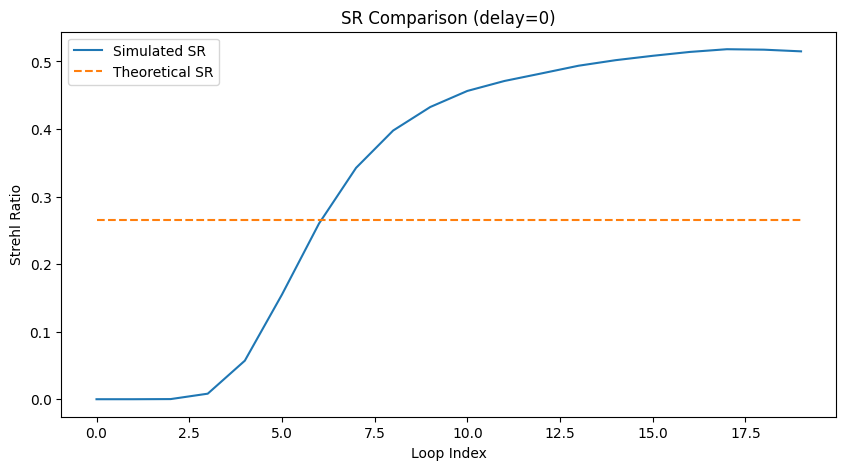

(array([9.01763268e-13, 2.26631569e-07, 2.06201838e-04, 8.20863213e-03,
        5.70492738e-02, 1.54771442e-01, 2.60016550e-01, 3.42472232e-01,
        3.97708302e-01, 4.32513249e-01, 4.56300787e-01, 4.71044473e-01,
        4.82246330e-01, 4.93632626e-01, 5.01851691e-01, 5.08314525e-01,
        5.14050730e-01, 5.18061525e-01, 5.17386876e-01, 5.14909831e-01]),
 array([662.15063689, 663.27098939, 664.46451111, 665.65564437,
        666.86109622, 668.0216194 , 669.07568295, 670.14140376,
        671.24723107, 672.33907518, 673.52582633, 674.71676017,
        675.88768663, 677.01679738, 678.10720155, 679.28835421,
        680.54414562, 681.83949699, 683.18587707, 684.51511452]),
 array([662.15063689, 491.804037  , 366.28193391, 275.53960319,
        212.77548696, 171.74355337, 145.92598466, 130.15367098,
        120.7316868 , 115.108159  , 111.37102679, 109.0907245 ,
        107.37431361, 105.64243706, 104.39959458, 103.42626267,
        102.56507348, 101.96435031, 102.06531758, 102.436303

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import time

def run(photonNoise=False, readoutNoise=0, darkCurrent=0, n=20, delay=0):
    wfs.cam.photonNoise = photonNoise
    wfs.cam.readoutNoise = readoutNoise
    wfs.cam.darkCurrent = darkCurrent

    atm.initializeAtmosphere(tel)
    dm.coefs = 0
    tel + atm
    ngs * tel * dm * wfs  

    SR          = np.zeros(n) # 实际 SR
    total       = np.zeros(n)
    residual    = np.zeros(n)
    coefs_list  = np.zeros(n)
    SR_theory   = np.zeros(n) # 理论 SR 曲线

    # ---- 计算有效风速 ----
    v_eff = (np.sum([f * (v**(5/3)) for f, v in zip(atm.fractionalR0, atm.windSpeed)]))**(3/5)

    # ---- DM 子孔径间距 ----
    D = tel.D
    d = D / dm.nAct
    r0 = atm.r0
    dt = tel.samplingTime

    wfs_buffer = deque([np.zeros(wfs.nSignal)] * (delay+1), maxlen=delay+1)

    for i in range(n):
        atm.update()
        total[i] = np.std(tel.OPD[np.where(tel.pupil>0)]) * 1e9

        tel * dm * wfs
        current_signal = wfs.signal.copy()
        wfs_buffer.append(current_signal)
        delayed_signal = wfs_buffer[0]

        dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ delayed_signal
        coefs_list[i] = np.sum(dm.coefs)

        # ---- 实际 SR ----
        SR[i] = np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
        residual[i] = np.std(tel.OPD[np.where(tel.pupil>0)]) * 1e9

        # ---- 理论 SR ----
        tau = (delay + 0.5) * dt
        sigma_fit   = 0.28 * (d/r0)**(5/3)
        sigma_servo = (v_eff * tau / r0)**(5/3)

        sigma2_total = sigma_fit + sigma_servo
        SR_theory[i] = np.exp(-sigma2_total)

        print(f"Loop {i}/{n}, SR={SR[i]:.3f}, SR_theory={SR_theory[i]:.3f}")

    # ---- 画图对比 ----
    plt.figure(figsize=(10,5))
    plt.plot(SR, label="Simulated SR")
    plt.plot(SR_theory, label="Theoretical SR", linestyle="--")
    plt.xlabel("Loop Index")
    plt.ylabel("Strehl Ratio")
    plt.legend()
    plt.title(f"SR Comparison (delay={delay})")
    plt.show()

    return SR, total, residual, coefs_list, SR_theory
run()